<a href="https://colab.research.google.com/github/MohammadYusif/time-series-forecasting-ai-systems/blob/main/day1/02_lab_arima_ets.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>


## Lab 2 — Classical Forecasting: ARIMA & Exponential Smoothing

Hands-on companion to [02_classical_models](02_classical_models.qmd) — objective 2 of this course. Using the same Riyadh/Grocery series and the same holdout convention as every lab in this course, we fit a SARIMAX chosen by a small AIC search, a Holt-Winters model, and a seasonal-naive baseline, forecast a 60-day holdout with each, and check the winning model's residuals for leftover structure.

By the end you will have:

- run a real (small, bounded) order search over SARIMAX candidates and picked one by AIC,
- fit Holt-Winters and a seasonal-naive baseline on the exact same train/test split,
- scored all three with MAE/RMSE/WAPE/MASE from `common/metrics.py`, and
- run the Ljung-Box test on the winning model's residuals and read what it does and doesn't tell you.

In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "statsmodels")

import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Locate rel_path from a repo checkout (tries rel_path and ../rel_path
    — labs live one directory below the repo root) or download it from
    GitHub if neither exists (a fresh Colab runtime)."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mape, smape, wape, mase, pinball_loss, coverage, interval_width

sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import seasonal_naive_forecast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)


### Load and split — same convention as every lab in this course

Time-ordered holdout: the last 60 days are test, everything before is train. **Never shuffle a time series before splitting it** — a random split would let the model train on days that come after the days it's being tested on, which is exactly the mistake `day2/04_backtesting.qmd` spends a whole lesson on. This lab's single split is itself a simplification Lab 4 will revisit with several folds instead of one.

train: 2023-01-01 .. 2025-11-01 (1036 days)
test:  2025-11-02 .. 2025-12-31 (60 days)


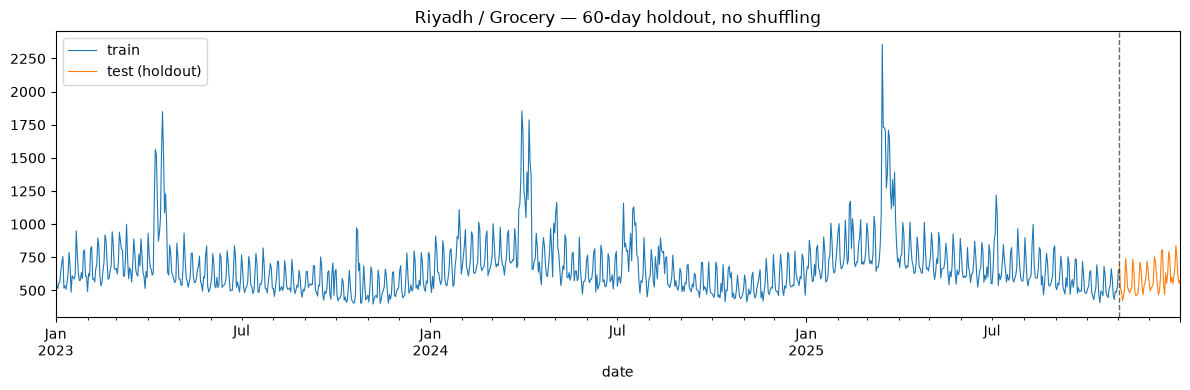

In [2]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
riyadh_grocery = df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")].copy()
riyadh_grocery = riyadh_grocery.set_index("date")["units_sold"].asfreq("D")

HORIZON = 60
train = riyadh_grocery.iloc[:-HORIZON]
test = riyadh_grocery.iloc[-HORIZON:]

print(f"train: {train.index.min().date()} .. {train.index.max().date()} ({len(train)} days)")
print(f"test:  {test.index.min().date()} .. {test.index.max().date()} ({len(test)} days)")

fig, ax = plt.subplots(figsize=(12, 4))
train.plot(ax=ax, linewidth=0.8, label="train")
test.plot(ax=ax, linewidth=0.8, label="test (holdout)")
ax.axvline(test.index[0], color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("Riyadh / Grocery — 60-day holdout, no shuffling")
ax.legend()
plt.tight_layout()
plt.show()


### A small SARIMAX order search, selected by AIC

Lab 1's ACF/PACF read suggested a short AR/MA order plus a seasonal term at `s=7`. Rather than guess one order, we search a small, bounded grid of candidates and let AIC — not intuition — pick the winner. This is a teaching-scale search (27 x 8 = 216 candidates, most converging in well under a second each); a production search would likely go wider, but the *method* — fit several, compare AIC, pick the minimum — is the same at any scale.

In [3]:
import itertools
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # SARIMAX is chatty about convergence during a grid search

# A small, deliberately cheap grid — this is a teaching example of ORDER
# SELECTION BY AIC, not an exhaustive production search. Lab 1's ACF/PACF
# read pointed at a short AR/MA order plus a seasonal term at s=7; this
# grid brackets that read rather than searching blindly.
p_range = d_range = q_range = range(0, 3)
P_range = D_range = Q_range = range(0, 2)
SEASONAL_PERIOD = 7

results = []
for p, d, q in itertools.product(p_range, d_range, q_range):
    for P, D, Q in itertools.product(P_range, D_range, Q_range):
        try:
            model = SARIMAX(
                train,
                order=(p, d, q),
                seasonal_order=(P, D, Q, SEASONAL_PERIOD),
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fit = model.fit(disp=False)
            results.append({"order": (p, d, q), "seasonal_order": (P, D, Q, SEASONAL_PERIOD), "aic": fit.aic})
        except Exception:
            continue  # a handful of orders fail to converge — skip, don't crash the search

results_df = pd.DataFrame(results).sort_values("aic").reset_index(drop=True)
print(f"{len(results_df)} / {len(list(itertools.product(p_range, d_range, q_range))) * len(list(itertools.product(P_range, D_range, Q_range)))} candidate orders converged")
print(results_df.head(8).to_string(index=False))

best = results_df.iloc[0]
print(f"\nBest by AIC: order={best['order']}, seasonal_order={best['seasonal_order']}, AIC={best['aic']:.2f}")


216 / 216 candidate orders converged
    order seasonal_order          aic
(1, 1, 2)   (0, 1, 1, 7) 12264.838990
(1, 0, 2)   (1, 1, 1, 7) 12269.368261
(2, 1, 1)   (1, 1, 1, 7) 12270.124682
(2, 0, 2)   (0, 1, 1, 7) 12271.494330
(2, 1, 2)   (0, 1, 1, 7) 12272.032053
(1, 0, 2)   (0, 1, 1, 7) 12274.515238
(2, 1, 1)   (0, 1, 1, 7) 12275.330714
(2, 0, 1)   (1, 1, 1, 7) 12278.471040

Best by AIC: order=(1, 1, 2), seasonal_order=(0, 1, 1, 7), AIC=12264.84


### Fit the winning SARIMAX and forecast the holdout

In [4]:
best_order = best["order"]
best_seasonal_order = best["seasonal_order"]

sarima_fit = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(sarima_fit.summary().tables[0])

sarima_forecast = sarima_fit.get_forecast(steps=HORIZON).predicted_mean
sarima_forecast.index = test.index


                                      SARIMAX Results                                      
Dep. Variable:                          units_sold   No. Observations:                 1036
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 7)   Log Likelihood               -6127.419
Date:                             Sat, 12 Sep 2026   AIC                          12264.839
Time:                                     19:34:21   BIC                          12289.467
Sample:                                 01-01-2023   HQIC                         12274.191
                                      - 11-01-2025                                         
Covariance Type:                               opg                                         


### Holt-Winters (additive trend, additive seasonality)

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_fit = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=SEASONAL_PERIOD
).fit()

hw_forecast = hw_fit.forecast(HORIZON)
hw_forecast.index = test.index

alpha = hw_fit.params["smoothing_level"]
beta = hw_fit.params["smoothing_trend"]
gamma = hw_fit.params["smoothing_seasonal"]
print(f"Holt-Winters: alpha={alpha:.4f}, beta={beta:.4f}, gamma={gamma:.4f}")


Holt-Winters: alpha=0.7326, beta=0.0000, gamma=0.0000


### The baseline every model here has to beat

`seasonal_naive_forecast` from `common/backtest.py` simply repeats the last observed 7-day cycle forward. It costs nothing to compute and has no parameters to get wrong — which is exactly why it's the right floor to compare against.

In [6]:
naive_forecast_values = seasonal_naive_forecast(train.to_numpy(), horizon=HORIZON, period=SEASONAL_PERIOD)
naive_forecast = pd.Series(naive_forecast_values, index=test.index)


### All three forecasts against the actual holdout

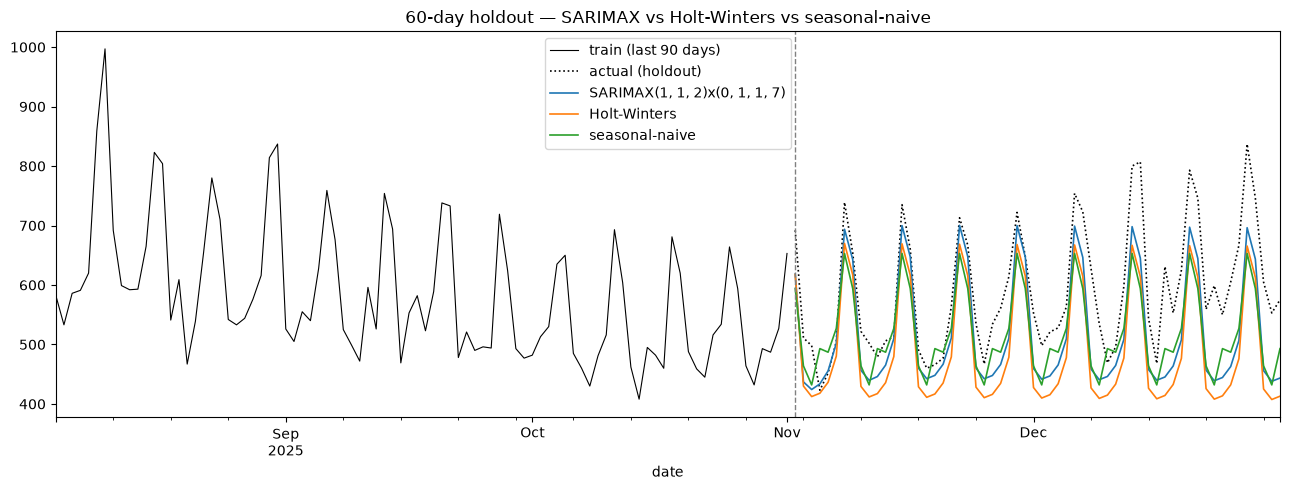

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-90:].plot(ax=ax, linewidth=0.8, color="black", label="train (last 90 days)")
test.plot(ax=ax, linewidth=1.2, color="black", linestyle=":", label="actual (holdout)")
sarima_forecast.plot(ax=ax, linewidth=1.2, label=f"SARIMAX{best_order}x{best_seasonal_order}")
hw_forecast.plot(ax=ax, linewidth=1.2, label="Holt-Winters")
naive_forecast.plot(ax=ax, linewidth=1.2, label="seasonal-naive")
ax.axvline(test.index[0], color="gray", linestyle="--", linewidth=1)
ax.set_title("60-day holdout — SARIMAX vs Holt-Winters vs seasonal-naive")
ax.legend()
plt.tight_layout()
plt.show()


### Scoring

`mase` is scaled against the seasonal-naive baseline computed on `train` itself (`seasonal_period=7`) — a value below 1.0 means a model beat that baseline; above 1.0 means it did worse than just repeating last week.

In [8]:
y_true = test.to_numpy()
y_train_arr = train.to_numpy()

rows = []
for name, y_pred in [
    ("SARIMAX", sarima_forecast.to_numpy()),
    ("Holt-Winters", hw_forecast.to_numpy()),
    ("seasonal-naive", naive_forecast.to_numpy()),
]:
    rows.append({
        "model": name,
        "mae": mae(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "wape": wape(y_true, y_pred),
        "mase": mase(y_true, y_pred, y_train_arr, seasonal_period=SEASONAL_PERIOD),
    })

scores = pd.DataFrame(rows).set_index("model").sort_values("mase")
scores.style.format("{:.3f}")


,mae,rmse,wape,mase
model,,,,
SARIMAX,71.190,86.263,12.053,0.785
seasonal-naive,78.133,91.609,13.228,0.862
Holt-Winters,99.745,111.925,16.887,1.100


### Residual diagnostics — Ljung-Box

A well-fit model's residuals should look like noise: no leftover autocorrelation for the model to have captured but didn't. Ljung-Box tests exactly that, at a chosen set of lags. Its null hypothesis is **"the residuals are independently distributed"** (i.e. no leftover autocorrelation) — so, reading the direction the same way Lab 1's ADF discussion did: a **low** p-value here is the *bad* outcome (reject the null → structure remains that the model missed), and a **high** p-value is what you want (residuals look like noise).

      lb_stat  lb_pvalue
7   12.039669   0.099262
14  31.101940   0.005364
21  36.207577   0.020720


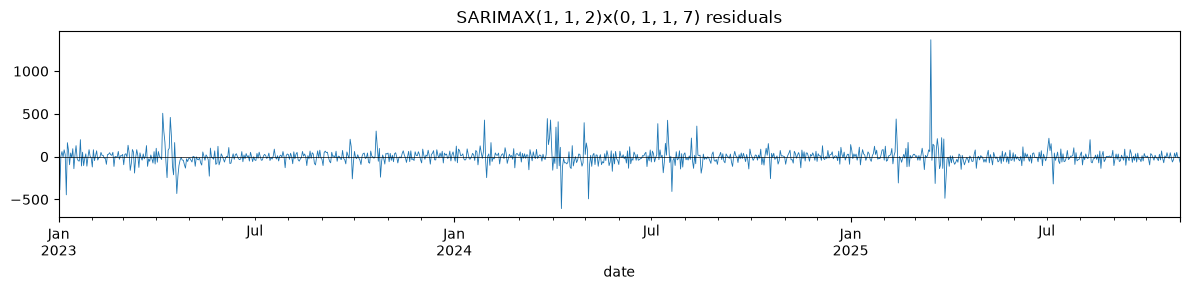

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(sarima_fit.resid, lags=[7, 14, 21], return_df=True)
print(lb)

fig, ax = plt.subplots(figsize=(12, 3))
sarima_fit.resid.plot(ax=ax, linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title(f"SARIMAX{best_order}x{best_seasonal_order} residuals")
plt.tight_layout()
plt.show()


## What actually happened

- **Order selected by AIC:** SARIMAX`(1, 1, 2)` x `(0, 1, 1, 7)` — the best
  of all 216/216 candidate orders in the grid that converged.
- **Holt-Winters degenerated on this series:** the fitted smoothing
  parameters came back `alpha=0.7326, beta=0.0000, gamma=0.0000` — the
  optimizer set both the trend and seasonal smoothing weights to zero,
  meaning the model effectively fell back to simple exponential smoothing
  with no real trend or seasonal component, despite being asked for both.
  This is a genuine, worth-noticing result, not a bug in the lab: additive
  Holt-Winters assumes seasonal swings of *roughly constant absolute size*,
  and this series' weekly swing grows with its level exactly the way
  `day2/03_feature_engineering.qmd`'s multiplicative-generator discussion
  describes — a model built for additive seasonality has a genuine reason
  to struggle here.
- **Scores on the 60-day holdout** (lower is better; MASE below 1.0 beats
  the seasonal-naive baseline it's scaled against):

  | model | mae | rmse | wape | mase |
  |---|--:|--:|--:|--:|
  | SARIMAX | 71.190 | 86.263 | 12.053 | 0.785 |
  | seasonal-naive | 78.133 | 91.609 | 13.228 | 0.862 |
  | Holt-Winters | 99.745 | 111.925 | 16.887 | 1.100 |

  **SARIMAX wins, and Holt-Winters actually loses to the naive baseline on
  this holdout** — not the tidy "every classical method beats naive" story
  a lesson might be tempted to tell, but the real result. It's a direct
  consequence of the degenerate fit above: a Holt-Winters model that isn't
  actually using its trend/seasonal terms has no real advantage left over
  seasonal-naive, and the small amount of daily noise put it slightly
  behind it on this particular 60-day window. (`day3/06_lab_model_comparison.ipynb`
  refits Holt-Winters fresh across 12 different, larger training windows
  on this same series and finds it winning there instead — a concrete
  illustration that a single split's verdict on a model family can be an
  artifact of exactly where that split happened to fall, not a stable
  property of the model. That is the whole reason
  `day2/04_backtesting.qmd` insists on more than one holdout.)
- **Ljung-Box on the SARIMAX residuals:** p=0.099 at lag 7, but p=0.005 at
  lag 14 and p=0.021 at lag 21 — both comfortably below 0.05. Reading the
  direction correctly (low p-value → reject the "residuals are independent"
  null → structure remains): this model has **not** fully whitened its
  residuals at the longer lags. Some autocorrelation the order search
  didn't capture is still there at 2-3 week horizons — plausibly related to
  the drifting holiday-style bumps `01_lab_decomposition.ipynb` found
  sitting in the STL residual, which a fixed `(P,D,Q)_7` seasonal term has
  no way to represent.

## Closing thoughts

The headline result here — SARIMAX beats a naive baseline that itself
beats Holt-Winters — is a single 60-day draw.
`day2/04_lab_backtesting_framework.ipynb` checks whether this exact
ranking survives being tested across several holdouts instead of one,
which is precisely the question a single split like this one cannot
answer on its own.

One honest limitation of everything on this page: the SARIMA order search
above only compares AIC across combinations of `(p,d,q)` and `(P,D,Q)` at a
fixed seasonal period. It never questions whether `s=7` itself was the right
seasonal period to search over in the first place — Lab 1's ACF/PACF read is
what justified that choice, not this cell. And the Ljung-Box result above is
a reason to want more than an AIC-selected order in practice — a real
project would likely also try adding exogenous regressors for the
holiday-style bumps rather than asking a bigger `(P,D,Q)_7` term to absorb
them.

Continue to Day 2: [03_feature_engineering](../day2/03_feature_engineering.qmd)
